<a href="https://colab.research.google.com/github/SangeetBarkataki10/CS105Minproject-SSTMA/blob/main/SSTMA_CS105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL Pipeline

In [56]:
import pandas as pd

df = pd.read_csv("CS105_data.csv")

column_mapping = {
    # Demographics
    2: "Class Standing",
    13: "Cumulative GPA",

    # AI Reliance
    42: "LLM Frequency (ChatGPT)",
    43: "LLM Frequency (Claude)",
    44: "LLM Frequency (Gemini)",
    46: "LLM Frequency (Copilot)",
    47: "LLM Frequency (Perplexity)",
    48: "LLM Frequency (Deepseek)",
    86: "Math Usage",
    88: "CS Usage",
    89: "Data Science Usage",
    99: "AI Chatbot Usage",

    # Confidence in Original Work
    53: "Coding Self Confidence",
    54: "Research Self Confidence",
    55: "Data Analysis Self Confidence",
    56: "Writing Self Confidence",
    57: "Topic Summarization Self Confidence",
    107: "Agreement",
    62: "Overreliance Concern",
    59: "Loss of Learning Concern",

    # Trust in AI vs Need for Verification
    92: "Math Trust",
    94: "CS Trust",
    95: "Data Science Trust",
    61: "Hallucinations/Wrong Answers"
}

columns_to_keep = list(column_mapping.keys())
df_clean = df.iloc[:, columns_to_keep].copy()

rename_dict = {df.columns[i]: new_name for i, new_name in column_mapping.items()}
df_clean = df_clean.rename(columns=rename_dict)
df_clean.dropna(inplace=True)

df_clean.to_csv("CS105_data_clean.csv", index=False)

df_clean.head()

,Class Standing,Cumulative GPA,LLM Frequency (ChatGPT),LLM Frequency (Claude),LLM Frequency (Gemini),LLM Frequency (Copilot),LLM Frequency (Perplexity),LLM Frequency (Deepseek),Math Usage,CS Usage,...,Data Analysis Self Confidence,Writing Self Confidence,Topic Summarization Self Confidence,Agreement,Overreliance Concern,Loss of Learning Concern,Math Trust,CS Trust,Data Science Trust,Hallucinations/Wrong Answers
0,Senior,3.33 – 3.67,Use Frequently,Never Used,Used 1-2 times,Never Used,Never Used,Never Used,2.0,1.0,...,Fairly Confident,Very Confident,Very Confident,4.0,4 (Moderately influential),5 (Extremely influential),2.0,2.0,2.0,4 (Moderately influential)
1,Junior,3.67 – 4.0,Use Rarely,Never Used,Use Rarely,Use Rarely,Never Used,Never Used,2.0,3.0,...,Fairly Confident,Very Confident,Very Confident,1.0,5 (Extremely influential),4 (Moderately influential),4.0,4.0,4.0,3 (Partially Influential)
2,Junior,3.33 – 3.67,Use Frequently,Use Frequently,Use Rarely,Never Used,Never Used,Never Used,2.0,2.0,...,Somewhat Confident,Fairly Confident,Fairly Confident,2.0,3 (Partially Influential),2 (Somewhat influential),1.0,2.0,1.0,2 (Somewhat influential)
3,Senior,3.33 – 3.67,Use Frequently,Use Frequently,Used 1-2 times,Use Rarely,Never Used,Never Used,0.0,4.0,...,Somewhat Confident,Very Confident,Very Confident,5.0,5 (Extremely influential),5 (Extremely influential),5.0,5.0,0.0,2 (Somewhat influential)
4,Junior,3.33 – 3.67,Use Frequently,Never Used,Use Frequently,Use Frequently,Never Used,Use Rarely,2.0,2.0,...,Somewhat Confident,Somewhat Confident,Somewhat Confident,2.0,5 (Extremely influential),4 (Moderately influential),5.0,5.0,5.0,4 (Moderately influential)


## Student Confidence by Coursework Bar Chart

This chart shows how students rated their confidence across different coursework skills, such as coding, research, data analysis, writing, and topic summarization. The visual helps us see whether confidence is concentrated in higher categories like Mostly Confident and Very Confident, or whether certain skills show more lower-confidence responses. For the project question, this helps establish what students' self-confidence looks like before comparing it to their AI usage patterns.


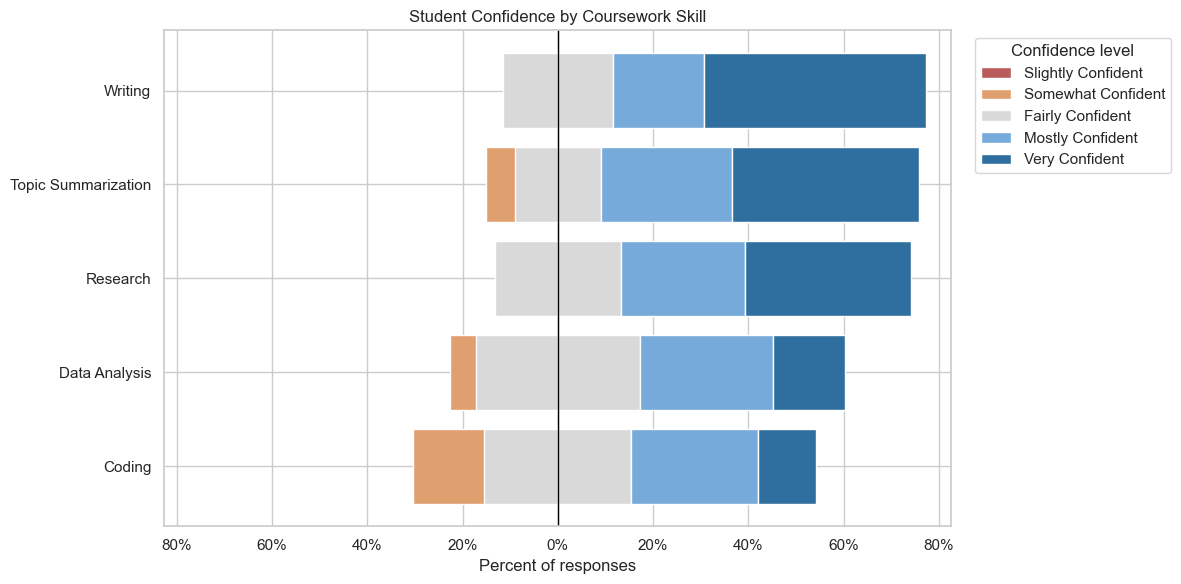

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

clean_df = pd.read_csv("CS105_data_clean.csv")

confidence_cols = [
    "Coding Self Confidence",
    "Research Self Confidence",
    "Data Analysis Self Confidence",
    "Writing Self Confidence",
    "Topic Summarization Self Confidence",
]

ai_usage_cols = ["Math Usage", "CS Usage", "Data Science Usage", "AI Chatbot Usage"]

confidence_order = [
    "Slightly Confident",
    "Somewhat Confident",
    "Fairly Confident",
    "Mostly Confident",
    "Very Confident",
]
confidence_score_map = {label: score for score, label in enumerate(confidence_order, start=1)}

for col in ai_usage_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

for col in confidence_cols:
    clean_df[f"{col} Score"] = clean_df[col].map(confidence_score_map)

clean_df["Average AI Usage"] = clean_df[ai_usage_cols].mean(axis=1)
clean_df["Average Confidence Score"] = clean_df[[f"{col} Score" for col in confidence_cols]].mean(axis=1)
clean_df["AI Usage Group"] = pd.cut(
    clean_df["Average AI Usage"],
    bins=[-0.01, 1.99, 3.99, 5.0],
    labels=["Low AI use", "Moderate AI use", "High AI use"],
)

likert_counts = (
    clean_df[confidence_cols]
    .melt(var_name="Skill", value_name="Confidence Level")
    .dropna()
)
likert_counts["Skill"] = likert_counts["Skill"].str.replace(" Self Confidence", "", regex=False)

likert_raw_counts = likert_counts.groupby(["Skill", "Confidence Level"]).size()
likert_pct = (
    (likert_raw_counts / likert_raw_counts.groupby(level=0).transform("sum") * 100)
    .unstack(fill_value=0)
    .reindex(columns=confidence_order, fill_value=0)
)

left_levels = ["Slightly Confident", "Somewhat Confident"]
center_level = "Fairly Confident"
right_levels = ["Mostly Confident", "Very Confident"]

fig, ax = plt.subplots(figsize=(12, 6))
colors = {
    "Slightly Confident": "#b85c5c",
    "Somewhat Confident": "#e09f6f",
    "Fairly Confident": "#d9d9d9",
    "Mostly Confident": "#75aadb",
    "Very Confident": "#2f6f9f",
}

y_positions = np.arange(len(likert_pct.index))

left_base = np.zeros(len(likert_pct))
for level in left_levels:
    values = -likert_pct[level].to_numpy()
    ax.barh(y_positions, values, left=left_base, color=colors[level], label=level)
    left_base += values

center_values = likert_pct[center_level].to_numpy()
ax.barh(y_positions, -center_values / 2, left=0, color=colors[center_level], label=center_level)
ax.barh(y_positions, center_values / 2, left=0, color=colors[center_level])

right_base = center_values / 2
for level in right_levels:
    values = likert_pct[level].to_numpy()
    ax.barh(y_positions, values, left=right_base, color=colors[level], label=level)
    right_base += values

ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y_positions)
ax.set_yticklabels(likert_pct.index)
ax.set_xlabel("Percent of responses")
ax.set_ylabel("")
ax.set_title("Student Confidence by Coursework Skill")

max_extent = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
ax.set_xlim(-max_extent, max_extent)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{abs(x):.0f}%"))
ax.legend(title="Confidence level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Box Plot: Confidence by AI Usage Level

This compares confidence score distributions for low, moderate, and high AI users. It helps show whether heavier AI use is linked with lower confidence, higher confidence, or simply more variation.


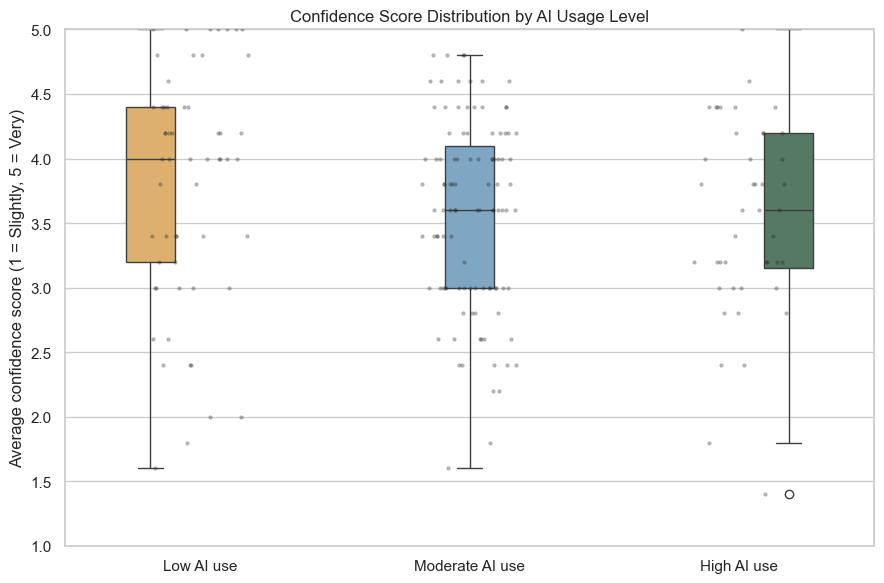

In [58]:
box_data = clean_df.dropna(subset=["AI Usage Group", "Average Confidence Score"]).copy()

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(
    data=box_data,
    x="AI Usage Group",
    y="Average Confidence Score",
    hue="AI Usage Group",
    order=["Low AI use", "Moderate AI use", "High AI use"],
    hue_order=["Low AI use", "Moderate AI use", "High AI use"],
    palette=["#f0b35e", "#74a9cf", "#4f7f62"],
    legend=False,
    width=0.55,
    ax=ax,
)
sns.stripplot(
    data=box_data,
    x="AI Usage Group",
    y="Average Confidence Score",
    order=["Low AI use", "Moderate AI use", "High AI use"],
    color="#252525",
    alpha=0.35,
    jitter=0.18,
    size=3,
    ax=ax,
)

ax.set_title("Confidence Score Distribution by AI Usage Level")
ax.set_xlabel("")
ax.set_ylabel("Average confidence score (1 = Slightly, 5 = Very)")
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()


## Hypothesis Testing

This hypothesis connects the EDA back to the project question by testing whether students' AI usage level is related to their confidence level.


### Hypothesis: AI usage group and confidence group are independent

**Test used:** Chi-squared test of independence. This test is appropriate because both variables are categorical: AI usage is grouped into low, moderate, and high use, while confidence is grouped into lower, moderate, and higher confidence.

**H0:** AI usage group and confidence group are independent.

**H1:** AI usage group and confidence group are associated.


In [ ]:
from scipy import stats

analysis_df = clean_df.dropna(subset=[
    "Average AI Usage",
    "Average Confidence Score",
    "AI Usage Group",
]).copy()

analysis_df["Confidence Group"] = pd.cut(
    analysis_df["Average Confidence Score"],
    bins=[0, 2.5, 3.5, 5],
    labels=["Lower confidence", "Moderate confidence", "Higher confidence"],
)

confidence_table = pd.crosstab(analysis_df["AI Usage Group"], analysis_df["Confidence Group"])
chi2, p_value, dof, expected = stats.chi2_contingency(confidence_table)

print("Observed counts:")
display(confidence_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Reject H0. Confidence group differs by AI usage group.")
else:
    print("Conclusion: Fail to reject H0. Confidence group does not differ significantly by AI usage group.")


**Result interpretation:** The chi-squared test does not show a statistically significant relationship between AI usage category and confidence category. This suggests that, when confidence is grouped into broad categories, the distribution of confidence levels is similar across low, moderate, and high AI users.
